In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df = pd.read_csv('../train_set/train_cleaned_outliers.csv')
test = pd.read_csv('../test_set/test_no_title.csv')
train = df.drop(columns=['originalTitle'])

# drop rating from train  and test
train = train.drop(columns=['rating'])
test = test.drop(columns=['rating'])

X_train = train.drop(columns=['averageRating'])
y_train = train['averageRating']
X_test = test.drop(columns=['averageRating', 'genreShort'])
y_test = test['averageRating']

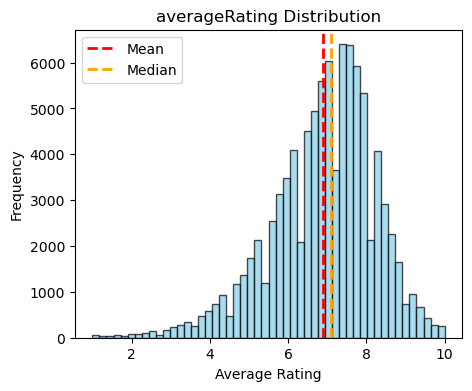

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
# Istogramma del target
ax.hist(train['averageRating'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax.axvline(train['averageRating'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
ax.axvline(train['averageRating'].median(), color='orange', linestyle='--', linewidth=2, label='Median')
ax.set_title('averageRating Distribution')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Frequency')
ax.legend()

plt.show()


In [ ]:
# from sklearn.experimental import enable_halving_search_cv
# from sklearn.model_selection import HalvingRandomSearchCV  # Import HalvingRandomSearchCV
# from scipy.stats import randint, uniform
# from sklearn.ensemble import RandomForestRegressor
# import numpy as np

# param_dist = {
#     'n_estimators': randint(50, 500),  # Da 50 a 1000 alberi
    
#     'max_depth': [5, 10, 15, 20, 25, 30, 40, 50, 70, 100],  # Include crescita completa
#     'min_samples_split': randint(2, 50),  # Da 2 a 50 campioni
#     'min_samples_leaf': randint(1, 30),   # Da 1 a 30 campioni per foglia
    
#     'max_features': ['sqrt', 'log2', 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    
#     'min_weight_fraction_leaf': uniform(0.0, 0.1),    # Peso minimo foglie
#     'max_leaf_nodes': [None, 100, 200, 500],  # Limite nodi foglia
#     'min_impurity_decrease': uniform(0.0, 0.01),      # Soglia miglioramento split
#     'max_samples': [None, 0.7, 0.8, 0.9, 1.0],       # Frazione campioni per albero
#     'ccp_alpha': uniform(0.0, 0.01)                   # Pruning post-costruzione
# }

# #  MODELLO OTTIMIZZATO per REGRESSIONE
# rf_regressor = RandomForestRegressor(
#     random_state=42,
#     n_jobs=-1,   
#     criterion = 'friedman_mse'       
#     verbose=0,         
# )

# #  HALVING RANDOM SEARCH per Random Forest
# _search = HalvingRandomSearchCV(
#     estimator=rf_regressor,
#     param_distributions=param_dist,
#     factor=2,                    
#     n_candidates = 500,
#     max_resources='auto',        
#     min_resources=500,     
#     scoring='neg_mean_squared_error',
#     cv=10,                        
#     verbose=1,                   
#     n_jobs=-1,                   
#     random_state=42,
# )

# # Fit del modello
# _search.fit(X_train, y_train)

# # Risultati
# print(f"\n🔧 Migliori parametri trovati:")
# for param, value in _search.best_params_.items():
#     print(f"  {param}: {value}")

# print(f"\n✅ Miglior score CV (MSE): {-_search.best_score_:.4f}")
# print(f"🏆 Numero iterazioni: {_search.n_iterations_}")
# print(f"📈 Candidati totali valutati: {len(_search.cv_results_['params'])}")

# # PROGRESSIONE HALVING SEARCH
# print("\n📊 HALVING SEARCH PROGRESSION:")
# results_df = pd.DataFrame(_search.cv_results_)
# iterations = sorted(results_df['iter'].unique())

# for iteration in iterations:
#     iter_data = results_df[results_df['iter'] == iteration]
#     n_candidates = len(iter_data)
#     best_score = iter_data['mean_test_score'].max()
#     resources_used = iter_data['n_resources'].iloc[0]
    
#     print(f"  Iteration {iteration}: {n_candidates:3d} candidates, "
#           f"best MSE: {-best_score:.4f}, resources: {resources_used}")


n_iterations: 8
n_required_iterations: 9
n_possible_iterations: 8
min_resources_: 500
max_resources_: 93240
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 500
n_resources: 500
Fitting 10 folds for each of 500 candidates, totalling 5000 fits


[CV] END ccp_alpha=0.003745401188473625, max_depth=50, max_features=0.3, max_leaf_nodes=200, max_samples=0.7, min_impurity_decrease=0.0015599452033620265, min_samples_leaf=11, min_samples_split=12, min_weight_fraction_leaf=0.08661761457749352, n_estimators=149; total time=   0.5s
[CV] END ccp_alpha=0.003745401188473625, max_depth=50, max_features=0.3, max_leaf_nodes=200, max_samples=0.7, min_impurity_decrease=0.0015599452033620265, min_samples_leaf=11, min_samples_split=12, min_weight_fraction_leaf=0.08661761457749352, n_estimators=149; total time=   0.3s
[CV] END ccp_alpha=0.003745401188473625, max_depth=50, max_features=0.3, max_leaf_nodes=200, max_samples=0.7, min_impurity_decrease=0.0015599452033620265, min_samples_leaf=11, min_samples_split=12, min_weight_fraction_leaf=0.08661761457749352, n_estimators=149; total time=   0.3s
[CV] END ccp_alpha=0.003745401188473625, max_depth=50, max_features=0.3, max_leaf_nodes=200, max_samples=0.7, min_impurity_decrease=0.0015599452033620265, mi

In [ ]:
# # save _search model
# import joblib
# joblib.dump(_search, 'rf.pkl')

['rf.pkl']

In [14]:
# load _search
_search = joblib.load('rf.pkl')


🎯 VALUTAZIONE SUL TEST SET:
📊 METRICHE FINALI:
  MAE:  0.8409
  MSE:  1.2775
  RMSE: 1.1303
  R²:   0.2857

🌟 TOP 10 FEATURE IMPORTANCES:
  titleType                : 0.4327
  startYearDecade          : 0.1421
  runtimeHours             : 0.1186
  genreDocumentary         : 0.0683
  numVotes                 : 0.0558
  genreHorror              : 0.0334
  genreDrama               : 0.0152
  totalMedia               : 0.0152
  totalRecognitions        : 0.0147
  companiesNumber          : 0.0119


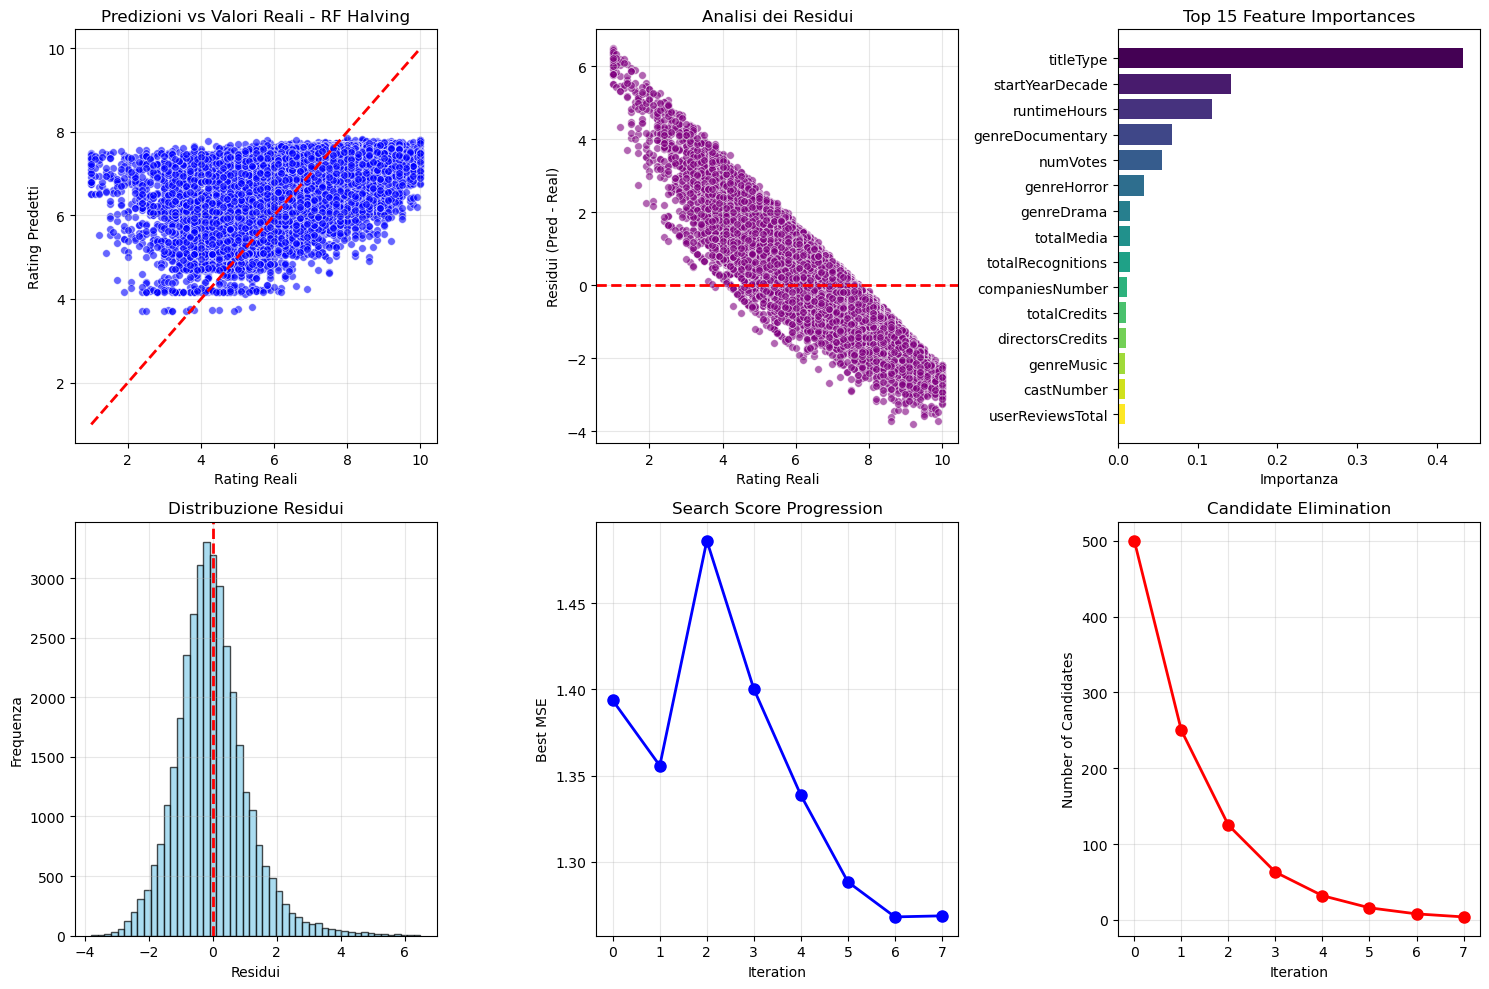


💾 Modello salvato come 'rf_halving.pkl'


In [ ]:

# VALUTAZIONE FINALE
print("\n🎯 VALUTAZIONE SUL TEST SET:")
best_model = _search.best_estimator_
y_pred = best_model.predict(X_test)

# Metriche per regressione
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"📊 METRICHE FINALI:")
print(f"  MAE:  {mae:.4f}")
print(f"  MSE:  {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²:   {r2:.4f}")

# ANALISI FEATURE IMPORTANCES
importances = best_model.feature_importances_
feature_names = X_train.columns

# Ordina per importanza
sorted_idx = np.argsort(importances)[::-1]

print(f"\n🌟 TOP 10 FEATURE IMPORTANCES:")
for i in range(min(10, len(feature_names))):
    idx = sorted_idx[i]
    print(f"  {feature_names[idx]:25s}: {importances[idx]:.4f}")

# VISUALIZZAZIONE
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

# Subplot 1: Predizioni vs Reali
plt.subplot(2, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.6, s=30, color='blue', edgecolors='white', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Rating Reali')
plt.ylabel('Rating Predetti')
plt.title('Predizioni vs Valori Reali - RF Halving')
plt.grid(True, alpha=0.3)

# Subplot 2: Residui
plt.subplot(2, 3, 2)
residuals = y_pred - y_test
plt.scatter(y_test, residuals, alpha=0.6, s=30, color='purple', edgecolors='white', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel('Rating Reali')
plt.ylabel('Residui (Pred - Real)')
plt.title('Analisi dei Residui')
plt.grid(True, alpha=0.3)

# Subplot 3: Feature Importances (Top 15)
plt.subplot(2, 3, 3)
top_n = min(15, len(feature_names))
colors = plt.cm.viridis(np.linspace(0, 1, top_n))
bars = plt.barh(range(top_n), importances[sorted_idx[:top_n]], color=colors)
plt.yticks(range(top_n), feature_names[sorted_idx[:top_n]])
plt.xlabel('Importanza')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()

# Subplot 4: Distribuzione Residui
plt.subplot(2, 3, 4)
plt.hist(residuals, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residui')
plt.ylabel('Frequenza')
plt.title('Distribuzione Residui')
plt.grid(True, alpha=0.3)

# Subplot 5: Halving Search Progression
plt.subplot(2, 3, 5)
iter_scores = []
iter_candidates = []

for iteration in iterations:
    iter_data = results_df[results_df['iter'] == iteration]
    iter_scores.append(iter_data['mean_test_score'].max())
    iter_candidates.append(len(iter_data))

plt.plot(iterations, [-score for score in iter_scores], 'bo-', linewidth=2, markersize=8)
plt.xlabel('Iteration')
plt.ylabel('Best MSE')
plt.title('Search Score Progression')
plt.grid(True, alpha=0.3)

# Subplot 6: Candidates Elimination
plt.subplot(2, 3, 6)
plt.plot(iterations, iter_candidates, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Iteration')
plt.ylabel('Number of Candidates')
plt.title('Candidate Elimination')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# SALVATAGGIO MODELLO
import joblib
joblib.dump(_search, 'rf_halving.pkl')
print("\n💾 Modello salvato come 'rf_halving.pkl'")

In [16]:
# Get the best parameters
best_params = _search.best_params_
print("Best parameters found: ", best_params)

# Evaluate the model with the best parameters
best_rf_regressor = _search.best_estimator_
y_pred = best_rf_regressor.predict(X_test)
# Calculate evaluation metrics  
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2}")

Best parameters found:  {'ccp_alpha': 1.3469300448532007e-06, 'max_depth': 100, 'max_features': 0.8, 'max_leaf_nodes': 100, 'max_samples': None, 'min_impurity_decrease': 0.0006268962162186587, 'min_samples_leaf': 18, 'min_samples_split': 9, 'min_weight_fraction_leaf': 0.00038199226585831084, 'n_estimators': 374}
Mean Squared Error: 1.2774702374802063
Mean Absolute Error: 0.8408650044179234
R^2 Score: 0.28567099011415154


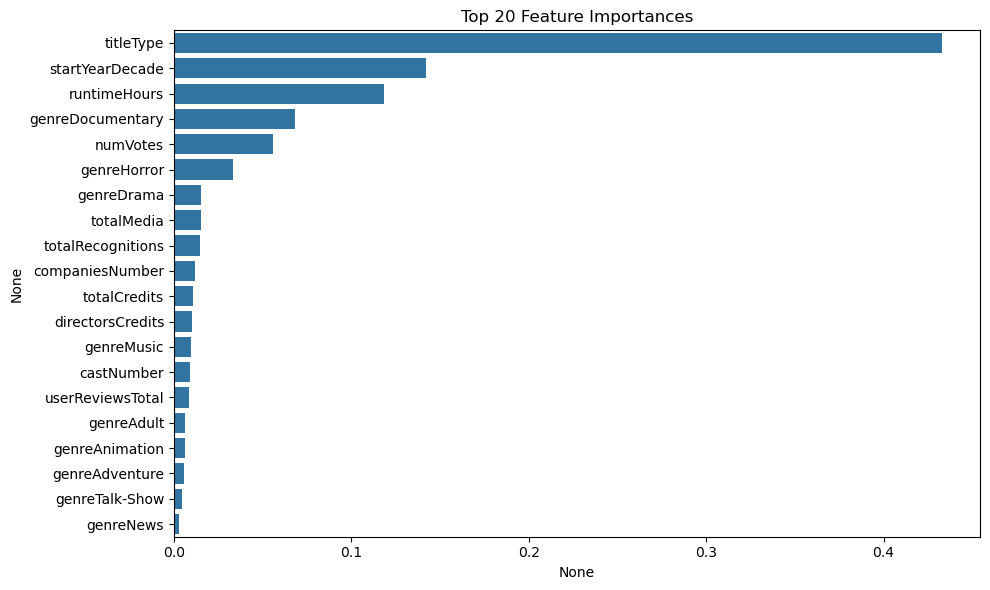

In [17]:
importances = best_rf_regressor.feature_importances_
features = X_train.columns

# Plotting feature importances
feature_importance = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance[:20], y=feature_importance.index[:20])
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()


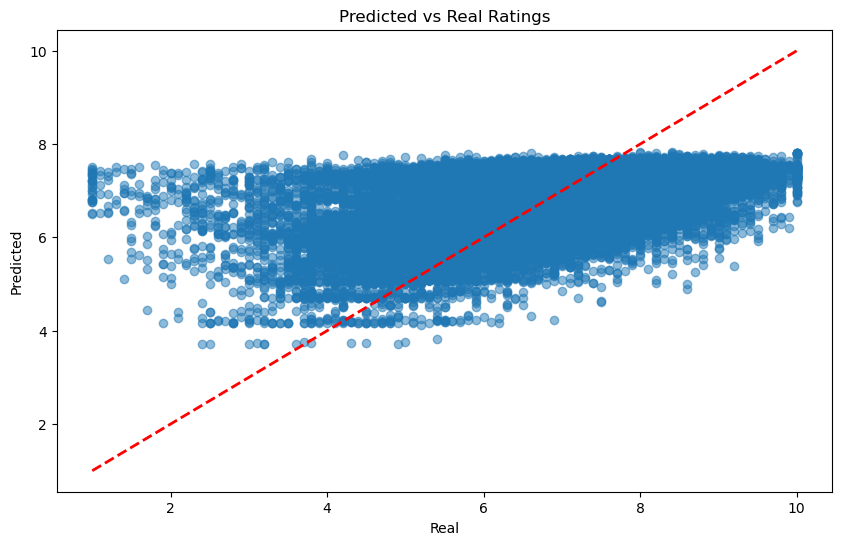

In [18]:
# plt for continuous predictions
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Real')
plt.ylabel('Predicted')
plt.title('Predicted vs Real Ratings')
plt.show()

/tmp/ipykernel_386064/3279247782.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby('range').agg(
/tmp/ipykernel_386064/3279247782.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='range', y='MAE', data=agg, palette=colors)
/tmp/ipykernel_386064/3279247782.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='range', y='MSE', data=agg, palette=colors)
/tmp/ipykernel_386064/3279247782.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be 

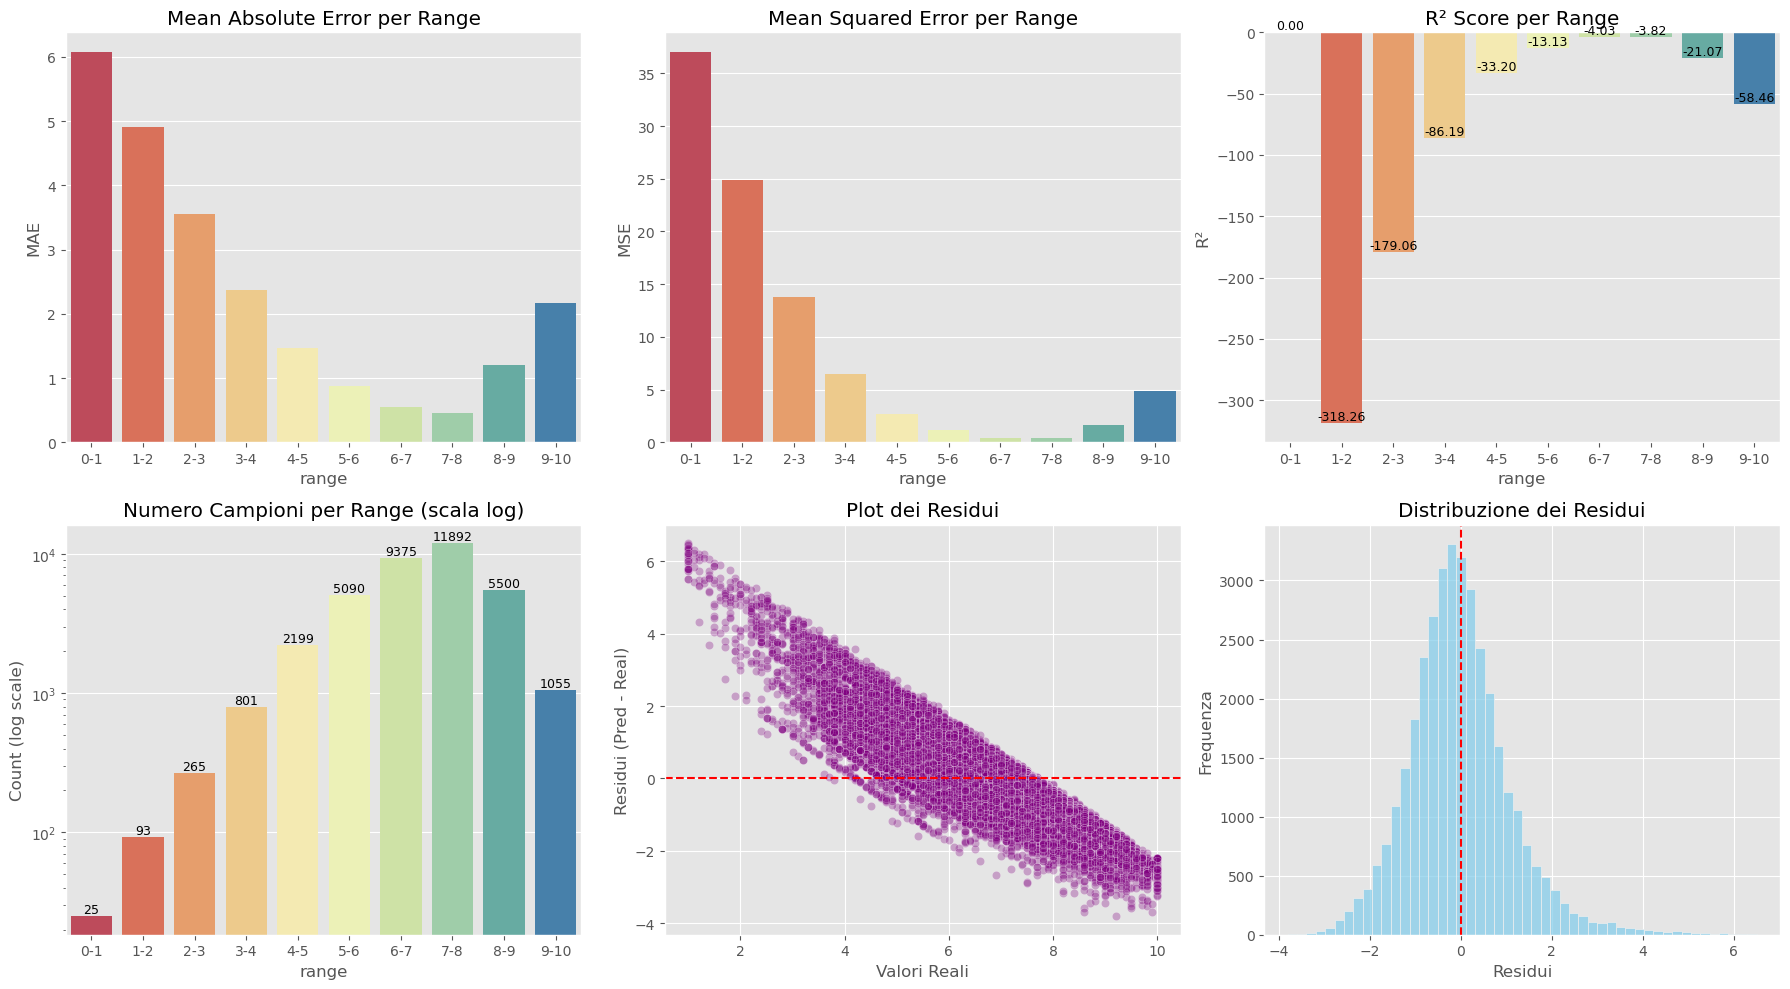

In [19]:
# Assumiamo che y_test e y_pred siano array numpy
df = pd.DataFrame({
    'true': y_test,
    'pred': y_pred
})
df['residuo'] = df['pred'] - df['true']

# Definition of bins and labels for ranges
bins = np.arange(0, 11, 1)
labels = [f"{i}-{i+1}" for i in range(0, 10)]
df['range'] = pd.cut(df['true'], bins=bins, labels=labels, include_lowest=True)

# Calcolo delle metriche per range
agg = df.groupby('range').agg(
    MAE=('residuo', lambda x: np.mean(np.abs(x))),
    MSE=('residuo', lambda x: np.mean(x**2)),
    R2=('residuo', lambda x: r2_score(df.loc[x.index, 'true'], df.loc[x.index, 'pred'])),
    Count=('residuo', 'count')
).reset_index()

# Set grafico
plt.figure(figsize=(18, 10))
plt.style.use('ggplot')
colors = sns.color_palette("Spectral", len(agg))

# MAE per range
plt.subplot(2, 3, 1)
sns.barplot(x='range', y='MAE', data=agg, palette=colors)
plt.title("Mean Absolute Error per Range")
plt.ylabel("MAE")

# MSE per range
plt.subplot(2, 3, 2)
sns.barplot(x='range', y='MSE', data=agg, palette=colors)
plt.title("Mean Squared Error per Range")
plt.ylabel("MSE")

# R2 per range
plt.subplot(2, 3, 3)
sns.barplot(x='range', y='R2', data=agg, palette=colors)
plt.title("R² Score per Range")
plt.ylabel("R²")
for i, val in enumerate(agg['R2']):
    plt.text(i, val, f"{val:.2f}", ha='center', va='bottom', fontsize=9)

# Numero di campioni (scala log)
plt.subplot(2, 3, 4)
sns.barplot(x='range', y='Count', data=agg, palette=colors)
plt.yscale("log")
plt.title("Numero Campioni per Range (scala log)")
plt.ylabel("Count (log scale)")
for i, val in enumerate(agg['Count']):
    plt.text(i, val, f"{val}", ha='center', va='bottom', fontsize=9)

# Plot dei residui
plt.subplot(2, 3, 5)
sns.scatterplot(x='true', y='residuo', data=df, alpha=0.3, color='purple')
plt.axhline(0, ls='--', color='red')
plt.title("Plot dei Residui")
plt.xlabel("Valori Reali")
plt.ylabel("Residui (Pred - Real)")

# Distribuzione dei residui
plt.subplot(2, 3, 6)
sns.histplot(df['residuo'], bins=50, kde=False, color='skyblue')
plt.axvline(0, ls='--', color='red')
plt.title("Distribuzione dei Residui")
plt.xlabel("Residui")
plt.ylabel("Frequenza")

plt.tight_layout()
plt.show()
